In [1]:
#Parameters
model_name = "retfound_green"
run_id = 0

In [2]:
# Multi image classification
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # allow multiple libiomp5md
os.environ["OMP_NUM_THREADS"] = "1"           # keep OpenMP under control

import torch
import albumentations as A
import numpy as np
import pandas as pd
from model import UnifiedBackbone
from fundus_dataset import FundusDataset
from torch.utils.data import DataLoader

C:\ProgramData\Anaconda3\envs\mBRSETnew\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
aug_type = 0
if model_name != "retfound_green":
    train_tf = A.Compose([
        A.RandomResizedCrop(height=392, width=392, scale=(0.7, 1.0), ratio=(0.75, 1.33)),
        A.HorizontalFlip(),
        A.VerticalFlip(),
        A.Normalize(mean=(0.485, 0.456, 0.406), 
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    
    val_tf = A.Compose([
        A.Resize(392, 392),
        A.Normalize(mean=(0.485, 0.456, 0.406), 
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
else:
    train_tf = A.Compose([
        A.RandomResizedCrop(height=392, width=392, scale=(0.7, 1.0), ratio=(0.75, 1.33)),
        A.HorizontalFlip(),
        A.VerticalFlip(),
        A.Normalize(mean=(0.5, 0.5, 0.5), 
                    std=(0.5, 0.5, 0.5)),
        ToTensorV2(),
    ])
    
    val_tf = A.Compose([
        A.Resize(392, 392),
        A.Normalize(mean=(0.5, 0.5, 0.5), 
                    std=(0.5, 0.5, 0.5)),
        ToTensorV2(),
    ])

In [4]:
from diagnosis_train_eval import validate
from torch.utils.data import DataLoader
import numpy as np
import torch
import torch.nn as nn

def compute_class_weights(df, threshold=0):
    labels = (df["final_icdr"] > threshold).astype(int).values
    class_counts = np.bincount(labels)
    weights = 1.0 / class_counts
    weights = weights / weights.sum()
    return torch.tensor(weights, dtype=torch.float32)
    

device = "cuda"

In [5]:
data_dir = r'C:\\Users\\preet\\Documents\\mBRSET\\mBRSET_image_quality\\data\\'

train_df_single = pd.read_pickle(data_dir + "mbrset_icdr_quality_2826_train_full.pkl")
val_df_single = pd.read_pickle(data_dir + "mbrset_icdr_quality_2826_val_full.pkl")
test_df_single = pd.read_pickle(data_dir + "mbrset_icdr_quality_2826_test_full.pkl")

train_df_single.drop(columns = ["Unnamed: 0"], inplace=True)
val_df_single.drop(columns = ["Unnamed: 0"], inplace=True)
test_df_single.drop(columns = ["Unnamed: 0"], inplace=True)

train_df_single.reset_index(drop=True, inplace=True)
val_df_single.reset_index(drop=True, inplace=True)
test_df_single.reset_index(drop=True, inplace=True)


In [6]:
img_root = r"C:\\Users\\preet\\Documents\\mBRSET\\mbrset-a-mobile-brazilian-retinal-dataset-1.0\\images"
train_ds_single = FundusDataset(train_df_single,img_root, high_quality_tf=train_tf, low_quality_tf=train_tf, label_col='final_icdr')
val_ds_single = FundusDataset(val_df_single,img_root, high_quality_tf=val_tf, low_quality_tf=val_tf, label_col='final_icdr')
test_ds_single = FundusDataset(test_df_single,img_root, high_quality_tf=val_tf, low_quality_tf=val_tf, label_col='final_icdr')

In [7]:

train_loader = DataLoader(train_ds_single, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds_single,   batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds_single,  batch_size=8, shuffle=False, num_workers=2)


In [8]:
import torch

loss_fn = torch.nn.CrossEntropyLoss()
device = 'cuda'
ba_target = 0.9

# Load trained diagnosis backbone
best_model = UnifiedBackbone(model_name=model_name).cuda().float()
best_model.load_state_dict(torch.load(r"C:\Users\preet\Documents\mBRSET\mBRSET_image_quality" + r"\mBRSET_img_diagnosis_model_392.pth"))

# Run validation
loss1, metrics_val, all_files, corr_files, incorrect_files = validate(
    best_model.float().cuda(), val_loader, loss_fn, device)   


# Attach image-level probabilities to validation set
df_probs_val = pd.DataFrame({
    "file": all_files,
    "prob": metrics_val["all_probs"]
})
df_val_eval = val_df_single.merge(df_probs_val, on="file", how="left")
# Run test evaluation
loss1, metrics_test, all_files, corr_files, incorrect_files = validate(
    best_model.float().cuda(), test_loader, loss_fn, device)

# Attach image-level probabilities to test set
df_probs_test = pd.DataFrame({
    "file": all_files,
    "prob": metrics_test["all_probs"]
})
df_test_eval = test_df_single.merge(df_probs_test, on="file", how="left")

Val:   0%|                                                                                                                                           | 0/84 [00:00<?, ?it/s]C:\ProgramData\Anaconda3\envs\mBRSETnew\lib\site-packages\timm\models\vision_transformer.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  x = F.scaled_dot_product_attention(
Val: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:18<00:00,  4.17it/s]


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

# Core constraints
num_imgs = 1


POOLING_METHOD = "mean"

# Fixed image-level confidence margins - atleast 3 images should be kept for every patient in mBRSET  
t_low  = 0.5 - 0.079
t_high = 0.5 + 0.079
if num_imgs == 1:
    img_idx = [0] 
if num_imgs == 2:
    img_idx = [0,2]
if num_imgs == 3:
    img_idx = [0,1,2]
if num_imgs == 4:
    img_idx = [0,1,2,3]
# Patient-level margins to sweep
patient_margins = [0.20, 0.25, 0.30, 0.35, 0.40]

results = []

from multi_image_val_test import compute_perf_metrics


df_val_eval = df_val_eval.sort_values(["patient", "file"])

for pat_margin in patient_margins:

    # Patient-level decision thresholds
    p_low  = 0.5 - pat_margin
    p_high = 0.5 + pat_margin

    coverage, ba, sens, spec, df_output = compute_perf_metrics(
        df_val_eval, t_low, t_high, p_low, p_high,
        num_imgs, "mBRSET", img_idx
    )
    results.append({
        "t_low": t_low,
        "t_high": t_high,
        "patient_margin": pat_margin,
        "p_low": p_low,
        "p_high": p_high,
        "coverage": coverage,
        "BA": ba,
        "sensitivity": sens,
        "specificity": spec
    })

results = pd.DataFrame(results)

In [11]:
from multi_image_val_test import determine_test_params

bin_size = 0.5
df_test_params = determine_test_params(results, bin_size)

In [13]:
test_results = []
for i in range(len(df_test_params)):
    row = df_test_params.iloc[i]
    coverage, ba, sens, spec, df_output = compute_perf_metrics(df_test_eval, row["t_low"], row["t_high"], row["p_low"], row["p_high"],
                                                               num_imgs, "mBRSET", img_idx)
    test_results.append({
        "t_low": row["t_low"],
        "t_high":  row["t_high"],
        "p_low":  row["p_low"],
        "p_high": row["p_high"],
        "coverage": coverage,
        "BA": ba,
        "sensitivity": sens,
        "specificity": spec
    })

#add 100% coverage point
coverage, ba, sens, spec, df_output = compute_perf_metrics(df_test_eval, 0.5, 0.5, 0.5, 0.5, num_imgs, "mBRSET", img_idx) 
test_results.append({
    "t_low": 0.5,
    "t_high":  0.5,
    "p_low":  0.5,
    "p_high": 0.5,
    "coverage": coverage,
    "BA": ba,
    "sensitivity": sens,
    "specificity": spec
})
test_results = pd.DataFrame(test_results)

In [14]:
data_result = r"C:\Users\preet\Documents\mBRSET\mBRSET_image_quality\results\mbrset_results"
test_results.to_csv(data_result + "\FINAL_"+str(num_imgs)+ "_mBRSET" + str(model_name) + "_21426_" + str(run_id) + ".csv")

## Choosing mBRSET images for Demo

In [17]:
patient_probs = df_test_eval.groupby("patient")["prob"].apply(list)
maxthres = 0.8
minthres = 0.2
patient_prob_dict = {
    patient: probs
    for patient, probs in patient_probs.items()
    if max(probs) > maxthres and min(probs) < minthres
}

patient_prob_dict


{419: [0.97802734375, 0.95947265625, 0.07684326171875, 0.1517333984375],
 662: [0.1695556640625, 0.039154052734375, 0.6748046875, 0.81787109375],
 750: [0.998046875, 0.302734375, 0.0775146484375, 0.2249755859375],
 817: [0.8349609375, 0.161865234375, 0.050750732421875, 0.051544189453125],
 883: [0.07781982421875, 0.493896484375, 0.82470703125, 0.716796875],
 943: [0.1900634765625, 0.84130859375, 0.42626953125, 0.43408203125],
 1027: [0.08843994140625, 0.892578125, 0.94287109375, 0.8974609375],
 1050: [0.96630859375, 0.99853515625, 0.07940673828125, 0.97705078125],
 1083: [0.80615234375, 0.48388671875, 0.5078125, 0.1593017578125],
 1219: [0.83203125, 0.57568359375, 0.6005859375, 0.1026611328125]}

In [18]:
# group probs per patient
patient_probs = df_test_eval.groupby("patient")["prob"].apply(list)

# check patient label = 0 (all images)
patient_labels = df_test_eval.groupby("patient")["final_icdr"].apply(set)

maxthres = 0.8
minthres = 0.2

patient_prob_dict = {
    patient: probs
    for patient, probs in patient_probs.items()
    if (
        len(probs) == 4
        and sum(minthres <= p <= maxthres for p in probs) == 2   # two between 0.2 and 0.8
        and sum(p < minthres for p in probs) == 2                # two below 0.2
        and patient_labels[patient] == {0}                       # label is zero
    )
}

patient_prob_dict


{128: [0.1480712890625, 0.29443359375, 0.114501953125, 0.2744140625],
 211: [0.476318359375, 0.281494140625, 0.0343017578125, 0.0433349609375],
 511: [0.07958984375, 0.32275390625, 0.06658935546875, 0.2095947265625],
 579: [0.144287109375, 0.037994384765625, 0.328369140625, 0.370361328125],
 587: [0.26806640625, 0.6728515625, 0.02044677734375, 0.04925537109375],
 705: [0.042816162109375, 0.08935546875, 0.250732421875, 0.449462890625],
 722: [0.426025390625, 0.053863525390625, 0.046783447265625, 0.6806640625],
 823: [0.1256103515625, 0.176025390625, 0.283447265625, 0.444580078125],
 856: [0.41259765625, 0.1778564453125, 0.66748046875, 0.08502197265625],
 926: [0.27685546875, 0.12445068359375, 0.07464599609375, 0.411376953125],
 958: [0.260009765625, 0.445068359375, 0.177001953125, 0.11273193359375],
 972: [0.09503173828125, 0.11492919921875, 0.46240234375, 0.310791015625],
 1152: [0.0675048828125, 0.393798828125, 0.1337890625, 0.2587890625],
 1224: [0.139404296875, 0.25927734375, 0.1280

In [19]:
df_test_eval.head()

,patient,file,final_icdr,final_quality,laterality,prob
0,5,5.1.jpg,False,0,True,0.666504
1,5,5.2.jpg,False,1,True,0.188232
2,5,5.3.jpg,False,1,False,0.316162
3,5,5.4.jpg,False,1,False,0.261719
4,9,9.1.jpg,False,1,True,0.075195


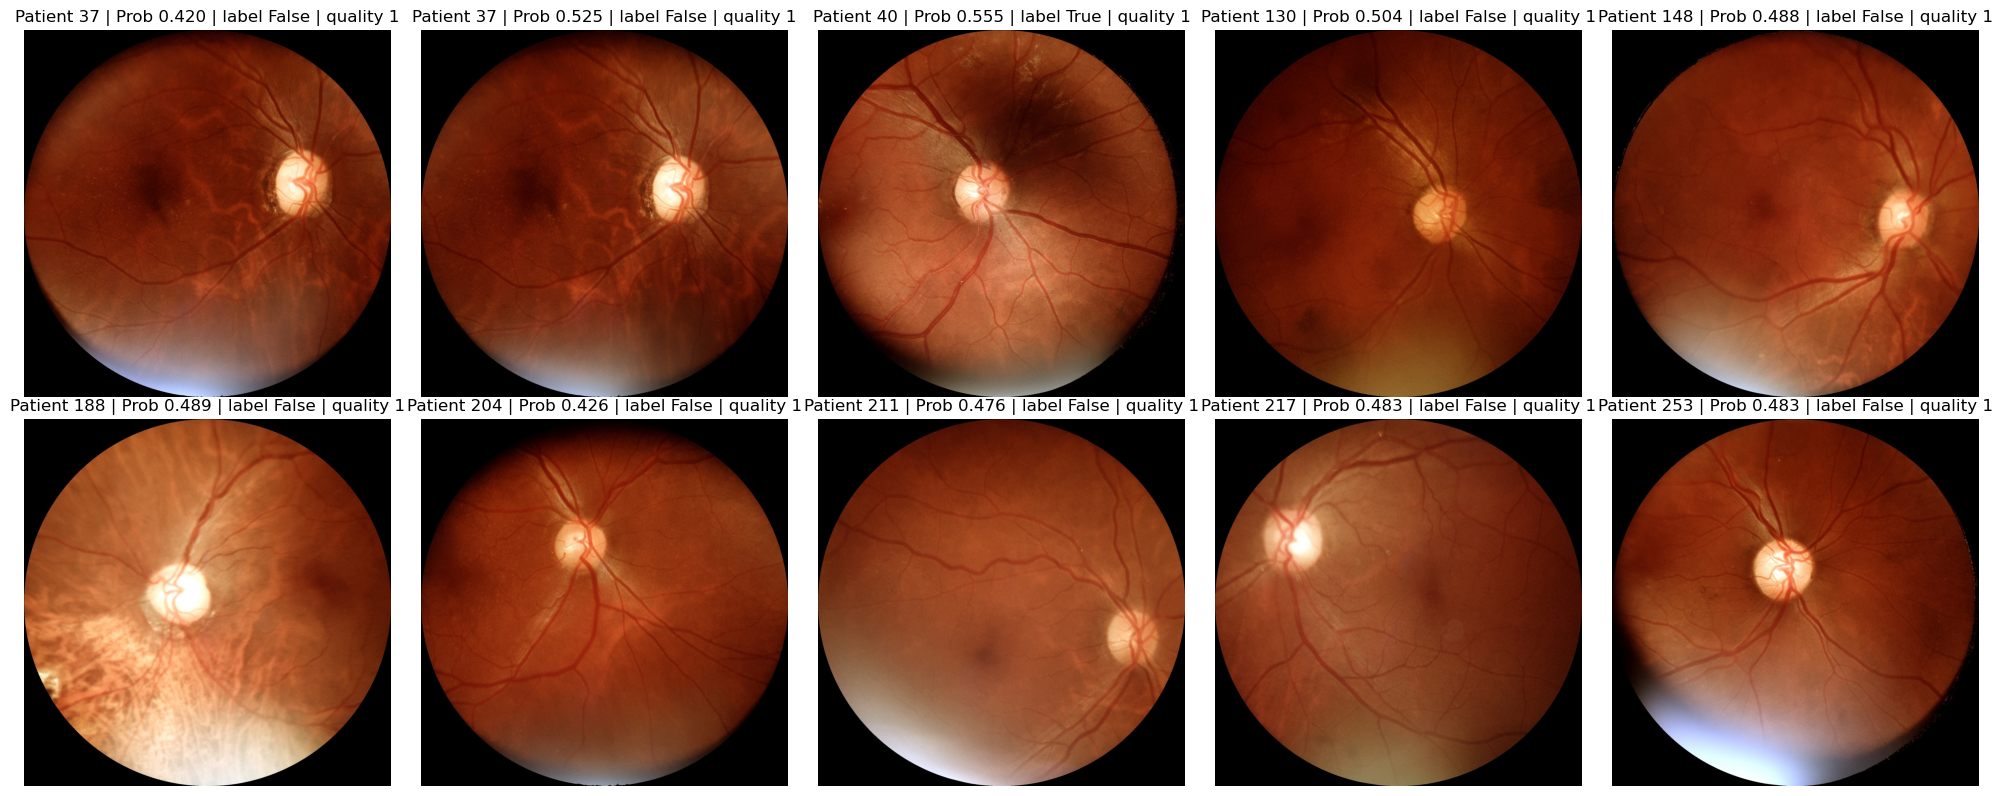

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# path to images
img_dir = r"C:\Users\preet\Documents\mBRSET\mbrset-a-mobile-brazilian-retinal-dataset-1.0\images"

# output folder
save_dir = r"C:\Users\preet\Documents\mBRSET\mbrset_lowconfidence"
os.makedirs(save_dir, exist_ok=True)

# number of images to visualize
N_SHOW = 10

# filter dataframe
df_mid = df_test_eval[(df_test_eval["prob"] >= 0.4) & (df_test_eval["prob"] <= 0.6)]

# take first N
df_show = df_mid.head(N_SHOW)

# grid layout
cols = 5
rows = int(np.ceil(len(df_show) / cols))

plt.figure(figsize=(4*cols, 4*rows))

for i, (_, row) in enumerate(df_show.iterrows()):

    img_path = os.path.join(img_dir, row["file"])
    img = Image.open(img_path)

    # ---- SAVE IMAGE ----
    save_name = f"patient_{row['patient']}_prob_{row['prob']:.3f}.png"
    save_path = os.path.join(save_dir, save_name)
    img.save(save_path)

    # ---- DISPLAY ----
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Patient {row['patient']} | Prob {row['prob']:.3f} | label {row['final_icdr']} | quality {row['final_quality']}"
    )

plt.tight_layout()
plt.show()

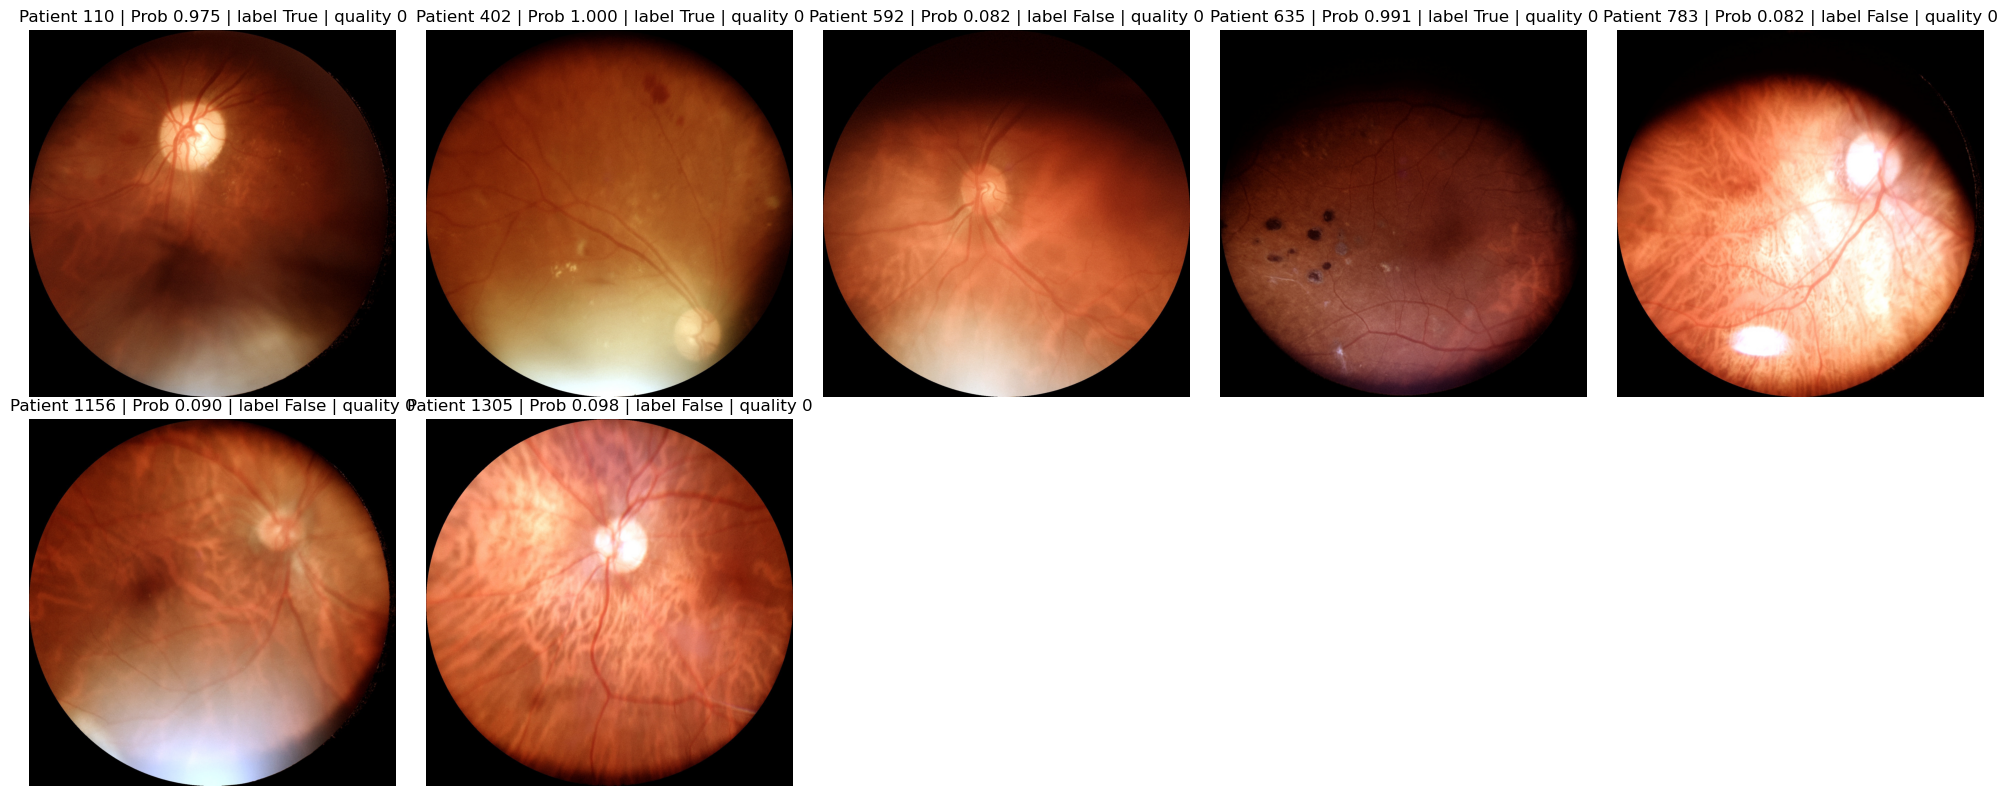

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# path to images
img_dir = r"C:\Users\preet\Documents\mBRSET\mbrset-a-mobile-brazilian-retinal-dataset-1.0\images"

# save directory
save_dir = r"C:\Users\preet\Documents\mBRSET\mbrset_highconfidence_lowquality_saliency"
os.makedirs(save_dir, exist_ok=True)

# number of images to visualize
N_SHOW = 20

# filter dataframe
df_mid = df_test_eval[
    (df_test_eval["final_quality"] == 0) &
    ((df_test_eval["prob"] >= 0.9) | (df_test_eval["prob"] <= 0.1))
]

# take first N
df_show = df_mid.head(N_SHOW)

# grid layout
cols = 5
rows = int(np.ceil(len(df_show) / cols))

plt.figure(figsize=(4*cols, 4*rows))

for i, (_, row) in enumerate(df_show.iterrows()):

    img_path = os.path.join(img_dir, row["file"])
    img = Image.open(img_path)

    # ---- SAVE IMAGE ----
    save_name = f"{row['file']}"
    save_path = os.path.join(save_dir, save_name)
    img.save(save_path)

    # ---- DISPLAY ----
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Patient {row['patient']} | Prob {row['prob']:.3f} | "
        f"label {row['final_icdr']} | quality {row['final_quality']}"
    )

plt.tight_layout()
plt.show()